# Daycare Project Analysis

**Name**: Eula Fullerton

**Class**: DSC640-T303 Data Presenation and Visualization

**Professor**: Benjamin Schneider

In [1]:
# import necessary libraries

import pandas as pd
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import geopandas as gpd
import geodatasets

# ignore warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

C:\Users\samue\anaconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
C:\Users\samue\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
C:\Users\samue\anaconda3\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,


In [2]:
# Load Excel file
file_path = 'NDCP2022.xlsx'

# Read the Excel file 
df = pd.read_excel(file_path, engine='openpyxl')

In [3]:
# List all columns (variables) in the dataset
df.columns.tolist()

['STATE_NAME',
 'STATE_ABBREVIATION',
 'COUNTY_NAME',
 'COUNTY_FIPS_CODE',
 'STUDYYEAR',
 'EMR_16',
 'FEMR_16',
 'MEMR_16',
 'EMR_20to64',
 'FEMR_20to64',
 'MEMR_20to64',
 'UNR_16',
 'FUNR_16',
 'MUNR_16',
 'UNR_20to64',
 'FUNR_20to64',
 'MUNR_20to64',
 'FLFPR_20to64',
 'FLFPR_20to64_UNDER6',
 'FLFPR_20to64_6to17',
 'FLFPR_20to64_UNDER6_6to17',
 'MLFPR_20to64',
 'PR_F',
 'PR_P',
 'MHI',
 'MFI',
 'MFI_2022',
 'ME',
 'FME',
 'MME',
 'MHI_2022',
 'ME_2022',
 'FME_2022',
 'MME_2022',
 'TOTALPOP',
 'ONERACE',
 'ONERACE_W',
 'ONERACE_B',
 'ONERACE_I',
 'ONERACE_A',
 'ONERACE_H',
 'ONERACE_OTHER',
 'TWORACES',
 'HISPANIC',
 'HOUSEHOLDS',
 'H_UNDER6_BOTHWORK',
 'H_UNDER6_FWORK',
 'H_UNDER6_MWORK',
 'H_UNDER6_SINGLEM',
 'H_6to17_BOTHWORK',
 'H_6to17_FWORK',
 'H_6to17_MWORK',
 'H_6to17_SINGLEM',
 'EMP_M',
 'MEMP_M',
 'FEMP_M',
 'EMP_SERVICE',
 'MEMP_SERVICE',
 'FEMP_SERVICE',
 'EMP_SALES',
 'MEMP_SALES',
 'FEMP_SALES',
 'EMP_N',
 'MEMP_N',
 'FEMP_N',
 'EMP_P',
 'MEMP_P',
 'FEMP_P',
 'iEMR_16',
 

In [4]:
df.info()   # View data types and non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48308 entries, 0 to 48307
Columns: 370 entries, STATE_NAME to iFEMP_P_STATE
dtypes: float64(200), int64(167), object(3)
memory usage: 136.4+ MB


In [5]:
df.describe()  # Quick stats for numeric columns

,COUNTY_FIPS_CODE,STUDYYEAR,EMR_16,FEMR_16,MEMR_16,EMR_20to64,FEMR_20to64,MEMR_20to64,UNR_16,FUNR_16,...,iFEMP_SERVICE_STATE,iEMP_SALES_STATE,iMEMP_SALES_STATE,iFEMP_SALES_STATE,iEMP_N_STATE,iMEMP_N_STATE,iFEMP_N_STATE,iEMP_P_STATE,iMEMP_P_STATE,iFEMP_P_STATE
count,48308.000000,48308.000000,48308.000000,48308.000000,48308.000000,48308.000000,48308.000000,48308.000000,48308.000000,48308.00000,...,48308.0,48308.0,48308.0,48308.0,48308.0,48308.0,48308.0,48308.0,48308.0,48308.0
mean,31394.875362,2014.999959,54.860845,50.968001,58.979668,68.652289,63.531773,72.199414,7.113882,6.73711,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
std,16291.031838,4.320660,8.743072,7.994420,10.430401,9.963630,11.603856,11.953302,3.958656,4.06488,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,1001.000000,2008.000000,11.000000,13.600000,8.000000,11.200000,0.000000,7.700000,0.000000,0.00000,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
25%,19032.500000,2011.000000,49.500000,46.000000,52.900000,63.100000,58.300000,66.300000,4.500000,4.10000,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
50%,30025.000000,2015.000000,55.600000,51.400000,60.200000,69.900000,65.200000,74.200000,6.400000,6.10000,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
75%,46107.000000,2019.000000,61.200000,56.500000,66.400000,75.700000,71.200000,80.700000,8.900000,8.50000,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
max,72153.000000,2022.000000,98.300000,100.000000,100.000000,99.100000,100.000000,102.300000,40.900000,45.00000,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [6]:
# View the available years
print("Years available:", df['STUDYYEAR'].unique())

Years available: [2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021
 2022]


## Explore childcare prices: Can Single Moms Afford Child Care? (2018-2022)

Focuses on both extremes: Top 5 worst and most affordable counties

Focused Variables:

**MCInfant: Median Price of Center-Based**
Care – Infant  
Aggregated weekly, full-time median  
price charged for Center-based Care 
for infants (i.e. aged 0 through 23 
months) 
Numeric  N/A

**MFCCInfant Median Price of Family Child**
Care – Infant  
Aggregated weekly, full-time median 
price charged for family child care 
for infants (i.e. aged 0 through 23 
months) 
Numeric  N/A

**FME Female Median Earnings Median earnings for females** (i.e. 
50th percentile)  
Numeric  S200

**STUDYYEAR**: 2018-2022

**H_UNDER6_SINGLEM**: Households with Children Under 6 with Single Mother 
Number of households with children 
under 6 years old with a single 
mother   
Numeric  B23008

The U.S. Department of Health and Human Services (HHS) defines affordable childcare as:

Childcare should cost no more than 7% of a family’s income.

This 7% benchmark is used:

As a policy guideline for subsidy eligibility,

In determining affordability for state childcare assistance programs,

In national reports to assess whether families are cost-burdened by childcare.

## Filter 2022 and Identify Top 5 Burdened and Affordable Counties for Single Mother Households

In [7]:
# Create df_trend filtered for 2018–2022
df_trend = df[df['STUDYYEAR'].between(2018, 2022)].copy()
df_trend['YEAR'] = df_trend['STUDYYEAR'].astype(int)

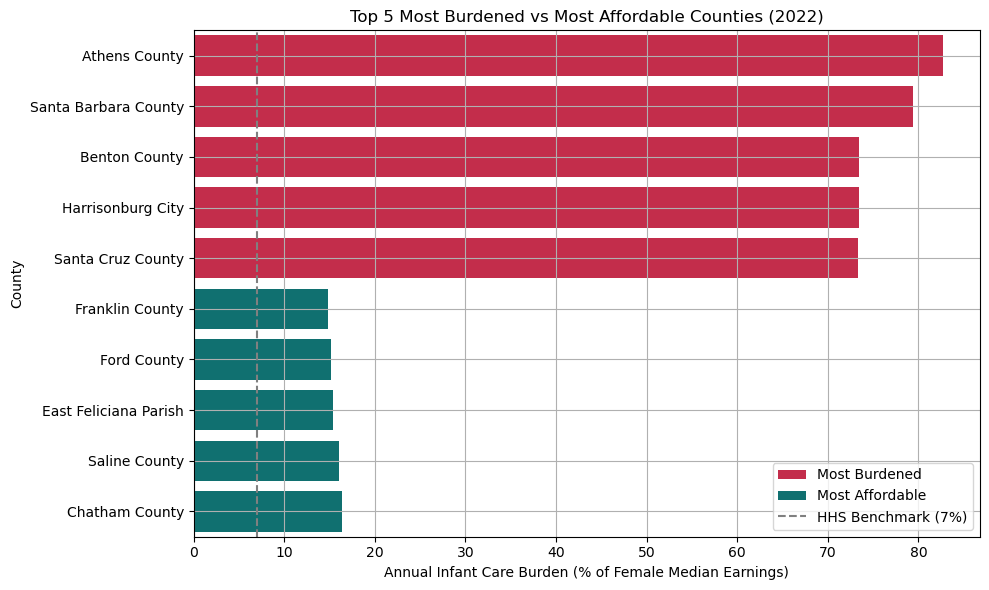

In [8]:
# Calculate annual infant care burden using Female Median Earnings (adjusted to 2022)
df_trend['annual_burden_pct_fme'] = (df_trend['MCINFANT'] * 52) / df_trend['FME_2022'] * 100
df_trend['annual_family_burden_pct_fme'] = (df_trend['MFCCINFANT'] * 52) / df_trend['FME_2022'] * 100

# Filter for 2022 and counties with substantial single-mom households
df_2022 = df_trend[df_trend['YEAR'] == 2022]
df_2022_moms = df_2022[df_2022['H_UNDER6_SINGLEM'] > 300]

# Identify top 5 most burdened and most affordable counties (based on FME_2022)
top5_worst = df_2022_moms.sort_values(by='annual_burden_pct_fme', ascending=False).head(5)
top5_best = df_2022_moms.sort_values(by='annual_burden_pct_fme', ascending=True).head(5)

# Label groups for visualization
top5_worst = top5_worst.copy()
top5_best = top5_best.copy()
top5_worst['Group'] = 'Most Burdened'
top5_best['Group'] = 'Most Affordable'
combined = pd.concat([top5_worst, top5_best])

# Plot: Bar chart comparing top 5 most burdened vs affordable counties
plt.figure(figsize=(10, 6))
sns.barplot(data=combined, y='COUNTY_NAME', x='annual_burden_pct_fme',
            hue='Group', dodge=False, palette=['crimson', 'teal'])

plt.axvline(7, linestyle='--', color='gray', label='HHS Benchmark (7%)')
plt.title('Top 5 Most Burdened vs Most Affordable Counties (2022)')
plt.xlabel('Annual Infant Care Burden (% of Female Median Earnings)')
plt.ylabel('County')
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

## improve visual

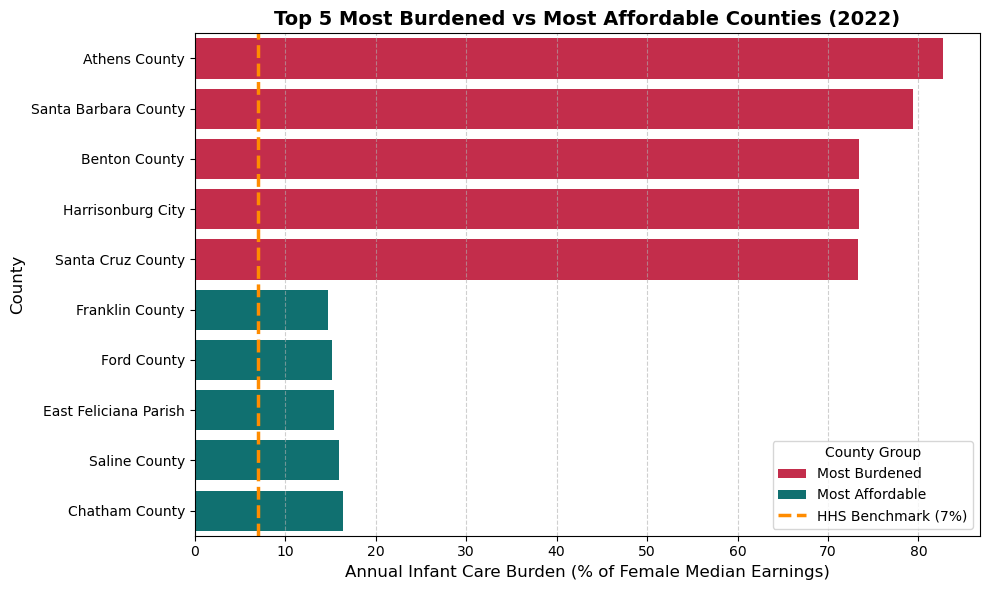

In [9]:
# Plot: Bar chart comparing top 5 most burdened vs affordable counties
plt.figure(figsize=(10, 6))
sns.barplot(data=combined, y='COUNTY_NAME', x='annual_burden_pct_fme',
            hue='Group', dodge=False, palette=['crimson', 'teal'])

# HHS Benchmark line with legend entry
plt.axvline(7, linestyle='--', color='darkorange', linewidth=2.5, label='HHS Benchmark (7%)')

# Add titles and labels
plt.title('Top 5 Most Burdened vs Most Affordable Counties (2022)', fontsize=14, fontweight='bold')
plt.xlabel('Annual Infant Care Burden (% of Female Median Earnings)', fontsize=12)
plt.ylabel('County', fontsize=12)
plt.legend(title='County Group')
plt.grid(True, axis='x', linestyle='--', alpha=0.6)

# Ensure spacing
plt.tight_layout()
plt.show()

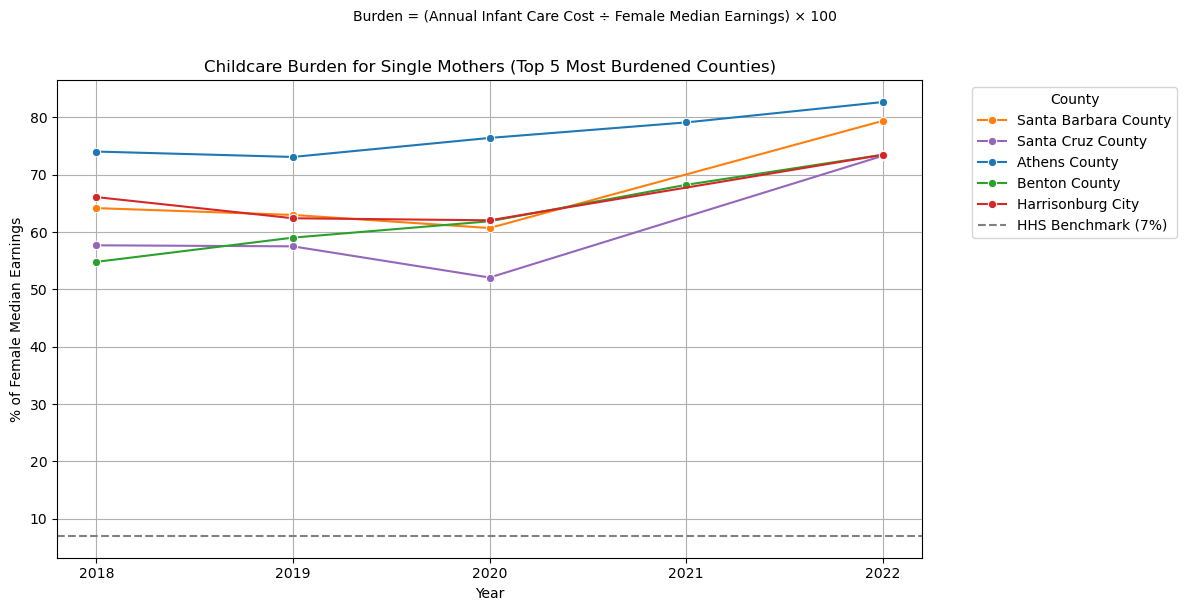

In [10]:
# Extract those counties for trendline analysis
top5_ids = top5_worst[['STATE_NAME', 'COUNTY_NAME']]
df_top5_trend = df_trend.merge(top5_ids, on=['STATE_NAME', 'COUNTY_NAME'])

# Sort counties for consistent color mapping
sorted_counties = top5_worst.sort_values(by='annual_burden_pct_fme', ascending=False)['COUNTY_NAME'].tolist()
palette = sns.color_palette("tab10")
county_palette = {county: palette[i] for i, county in enumerate(sorted_counties)}

# Plot: Trend line of burden over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_top5_trend, x='YEAR', y='annual_burden_pct_fme',
             hue='COUNTY_NAME', marker='o', palette=county_palette)

plt.axhline(7, linestyle='--', color='gray', label='HHS Benchmark (7%)')
plt.title('Childcare Burden for Single Mothers (Top 5 Most Burdened Counties)')
plt.suptitle('Burden = (Annual Infant Care Cost ÷ Female Median Earnings) × 100', fontsize=10, y=1.01)
plt.ylabel('% of Female Median Earnings')
plt.xlabel('Year')
plt.gca().xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.legend(title='County', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

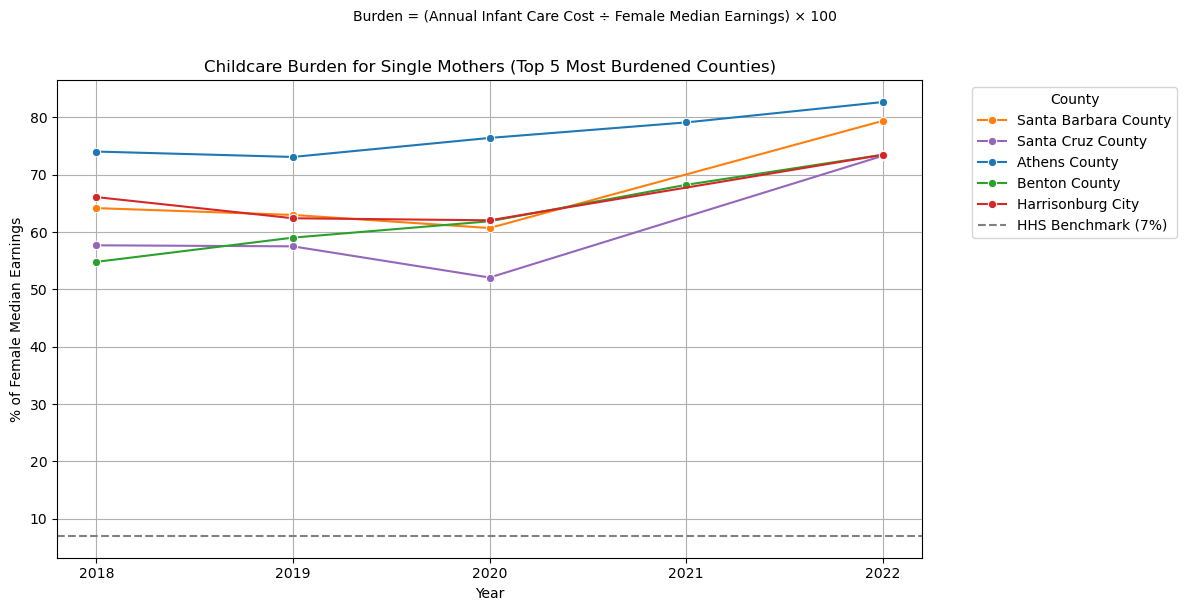

In [11]:
# Extract those counties for trendline analysis
top5_ids = top5_worst[['STATE_NAME', 'COUNTY_NAME']]
df_top5_trend = df_trend.merge(top5_ids, on=['STATE_NAME', 'COUNTY_NAME'])

# Sort counties for consistent color mapping
sorted_counties = top5_worst.sort_values(by='annual_burden_pct_fme', ascending=False)['COUNTY_NAME'].tolist()
palette = sns.color_palette("tab10")
county_palette = {county: palette[i] for i, county in enumerate(sorted_counties)}

# Plot: Trend line of burden over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_top5_trend, x='YEAR', y='annual_burden_pct_fme',
             hue='COUNTY_NAME', marker='o', palette=county_palette)

plt.axhline(7, linestyle='--', color='gray', label='HHS Benchmark (7%)')
plt.title('Childcare Burden for Single Mothers (Top 5 Most Burdened Counties)')
plt.suptitle('Burden = (Annual Infant Care Cost ÷ Female Median Earnings) × 100', fontsize=10, y=1.01)
plt.ylabel('% of Female Median Earnings')
plt.xlabel('Year')
plt.gca().xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.legend(title='County', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
cols_to_show = [
    'STATE_NAME',
    'COUNTY_NAME',
    'MCINFANT',
    'FME_2022',                 # add this
    'annual_burden_pct_fme',   # updated burden column
    'H_UNDER6_SINGLEM'
]

renamed_cols = {
    'STATE_NAME': 'State',
    'COUNTY_NAME': 'County',
    'MCINFANT': 'Weekly Infant Care Cost',
    'FME_2022': 'Female Median Earnings (2022)',
    'annual_burden_pct_fme': 'Annual Burden (% of Female Earnings)',
    'H_UNDER6_SINGLEM': 'Single-Mom Households in Area (<6 years)'
}

In [13]:
# Get top 5 most burdened counties (using FME-based burden)
top5_worst = df_2022_moms.sort_values(by='annual_burden_pct_fme', ascending=False).head(5).reset_index(drop=True)
top5_worst.insert(0, 'Rank', range(1, len(top5_worst) + 1))

# Format columns
top5_worst['MCINFANT'] = top5_worst['MCINFANT'].map('${:,.2f}'.format)
top5_worst['FME_2022'] = top5_worst['FME_2022'].map('${:,.0f}'.format)
top5_worst['annual_burden_pct_fme'] = top5_worst['annual_burden_pct_fme'].map('{:.1f}%'.format)
top5_worst['H_UNDER6_SINGLEM'] = top5_worst['H_UNDER6_SINGLEM'].astype(int).map('{:,}'.format)

# Display
display(Markdown("### Top 5 Most Burdened Counties by Annual Infant Care Cost Burden (2022)"))
display(top5_worst[['Rank'] + cols_to_show].rename(columns=renamed_cols))

### Top 5 Most Burdened Counties by Annual Infant Care Cost Burden (2022)

,Rank,State,County,Weekly Infant Care Cost,Female Median Earnings (2022),Annual Burden (% of Female Earnings),Single-Mom Households in Area (<6 years)
0,1,Ohio,Athens County,$295.00,"$18,556",82.7%,400
1,2,California,Santa Barbara County,$452.53,"$29,640",79.4%,"7,961"
2,3,Oregon,Benton County,$340.19,"$24,074",73.5%,496
3,4,Virginia,Harrisonburg City,$187.51,"$13,273",73.5%,490
4,5,California,Santa Cruz County,$476.88,"$33,834",73.3%,"3,319"


In [14]:
# Get top 5 most affordable counties (using FME-based burden)
top5_best = df_2022_moms.sort_values(by='annual_burden_pct_fme', ascending=True).head(5).reset_index(drop=True)
top5_best.insert(0, 'Rank', range(1, len(top5_best) + 1))

# Format columns
top5_best['MCINFANT'] = top5_best['MCINFANT'].map('${:,.2f}'.format)
top5_best['FME_2022'] = top5_best['FME_2022'].map('${:,.0f}'.format)
top5_best['annual_burden_pct_fme'] = top5_best['annual_burden_pct_fme'].map('{:.1f}%'.format)
top5_best['H_UNDER6_SINGLEM'] = top5_best['H_UNDER6_SINGLEM'].astype(int).map('{:,}'.format)

# Display
display(Markdown("### Top 5 Most Affordable Counties by Annual Infant Care Cost Burden (2022)"))
display(top5_best[['Rank'] + cols_to_show].rename(columns=renamed_cols))

### Top 5 Most Affordable Counties by Annual Infant Care Cost Burden (2022)

,Rank,State,County,Weekly Infant Care Cost,Female Median Earnings (2022),Annual Burden (% of Female Earnings),Single-Mom Households in Area (<6 years)
0,1,Kansas,Franklin County,$95.60,"$33,620",14.8%,408
1,2,Kansas,Ford County,$95.60,"$32,828",15.1%,875
2,3,Louisiana,East Feliciana Parish,$120.00,"$40,613",15.4%,401
3,4,Kansas,Saline County,$95.60,"$31,066",16.0%,"1,111"
4,5,Georgia,Chatham County,$102.50,"$32,453",16.4%,"8,001"


In [15]:
# Get top 5 counties with highest single-mom households in 2022
top5_single_moms = df_2022.sort_values(by='H_UNDER6_SINGLEM', ascending=False).head(5).reset_index(drop=True)
top5_single_moms.insert(0, 'Rank', range(1, len(top5_single_moms) + 1))

# Format columns to match your previous style
top5_single_moms['MCINFANT'] = top5_single_moms['MCINFANT'].map('${:,.2f}'.format)
top5_single_moms['FME_2022'] = top5_single_moms['FME_2022'].map('${:,.0f}'.format)
top5_single_moms['annual_burden_pct_fme'] = top5_single_moms['annual_burden_pct_fme'].map('{:.1f}%'.format)
top5_single_moms['H_UNDER6_SINGLEM'] = top5_single_moms['H_UNDER6_SINGLEM'].astype(int).map('{:,}'.format)

# Display
display(Markdown("### Top 5 Counties by Number of Single-Mom Households (2022)"))
display(top5_single_moms[['Rank'] + cols_to_show].rename(columns=renamed_cols))

### Top 5 Counties by Number of Single-Mom Households (2022)

,Rank,State,County,Weekly Infant Care Cost,Female Median Earnings (2022),Annual Burden (% of Female Earnings),Single-Mom Households in Area (<6 years)
0,1,California,Los Angeles County,$256.98,"$36,009",37.1%,"165,174"
1,2,Texas,Harris County,$185.00,"$33,573",28.7%,"115,198"
2,3,Illinois,Cook County,$278.33,"$41,198",35.1%,"96,537"
3,4,Arizona,Maricopa County,$270.00,"$38,582",36.4%,"77,126"
4,5,Texas,Dallas County,$194.00,"$35,038",28.8%,"63,034"


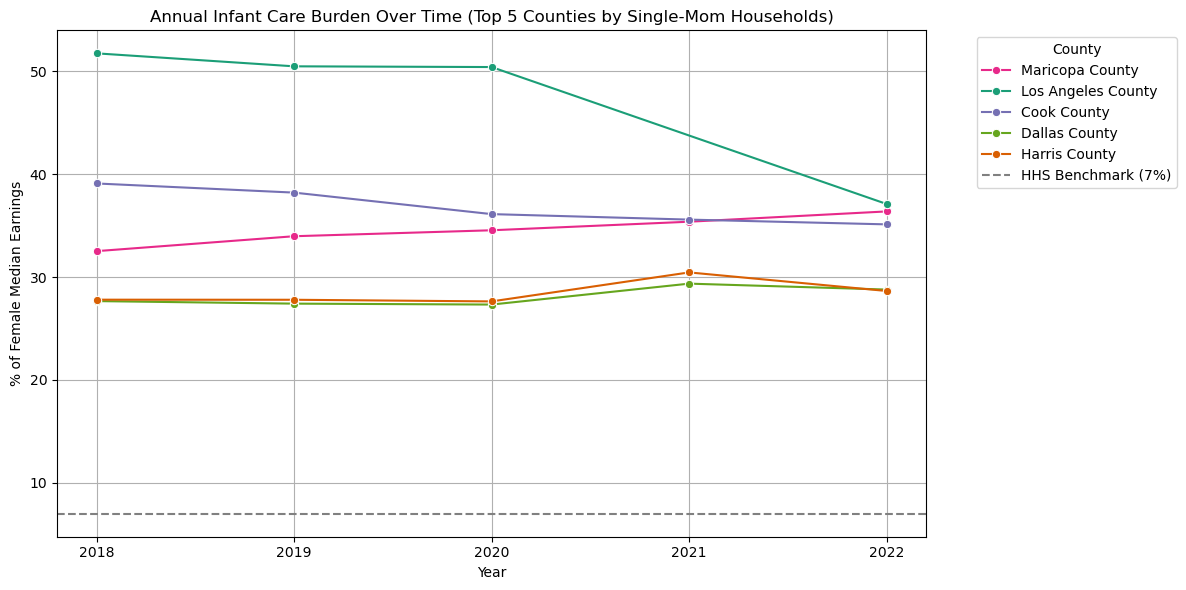

In [16]:
top5_single_moms = df_2022[df_2022['H_UNDER6_SINGLEM'] > 0] \
    .sort_values(by='H_UNDER6_SINGLEM', ascending=False).head(5).reset_index(drop=True)
top5_ids_single_moms = top5_single_moms[['STATE_NAME', 'COUNTY_NAME']]
df_top5_single_moms_trend = df_trend.merge(top5_ids_single_moms, on=['STATE_NAME', 'COUNTY_NAME'])
sorted_single_moms_counties = top5_single_moms['COUNTY_NAME'].tolist()
palette = sns.color_palette("Dark2")  # Or any palette you prefer
county_palette_single_moms = {county: palette[i] for i, county in enumerate(sorted_single_moms_counties)}

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_top5_single_moms_trend, x='YEAR', y='annual_burden_pct_fme',
             hue='COUNTY_NAME', marker='o', palette=county_palette_single_moms)

plt.axhline(7, linestyle='--', color='gray', label='HHS Benchmark (7%)')
plt.title('Annual Infant Care Burden Over Time (Top 5 Counties by Single-Mom Households)')
plt.ylabel('% of Female Median Earnings')
plt.xlabel('Year')
plt.gca().xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.legend(title='County', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.show()

## Infant Centervs Family Care, National burden 

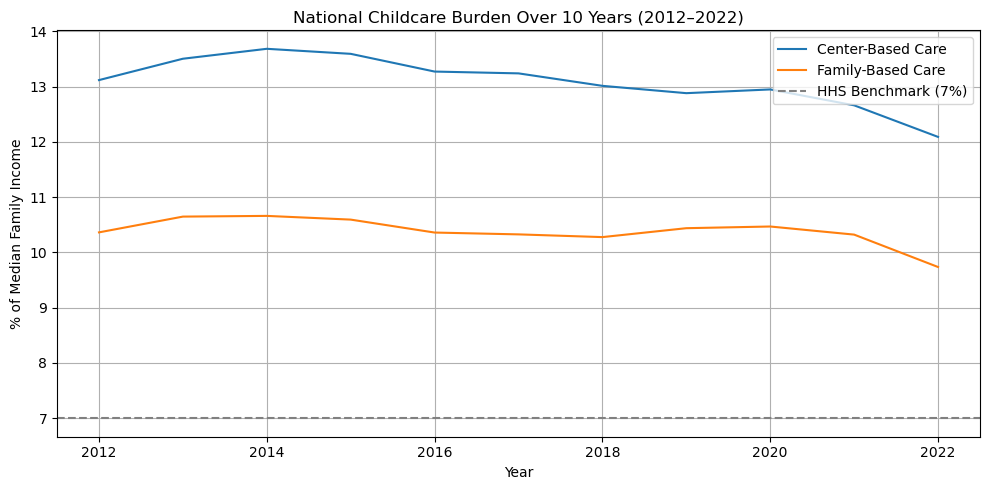

In [17]:
# Filter for 2012–2022 (or 2010+)
df_long = df[df['STUDYYEAR'] >= 2012].copy()
df_long['YEAR'] = df_long['STUDYYEAR'].astype(int)

# Burden calculations
df_long['annual_center_burden_pct'] = (df_long['MCINFANT'] * 52) / df_long['MFI'] * 100
df_long['annual_family_burden_pct'] = (df_long['MFCCINFANT'] * 52) / df_long['MFI'] * 100

# National burden over time (2012–2022)
national_10yr = df_long.groupby('YEAR')[['annual_center_burden_pct', 'annual_family_burden_pct']].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=national_10yr, x='YEAR', y='annual_center_burden_pct', label='Center-Based Care')
sns.lineplot(data=national_10yr, x='YEAR', y='annual_family_burden_pct', label='Family-Based Care')
plt.axhline(7, linestyle='--', color='gray', label='HHS Benchmark (7%)')
plt.title('National Childcare Burden Over 10 Years (2012–2022)')
plt.ylabel('% of Median Family Income')
plt.xlabel('Year')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Center vs Family Care Comparasion

## Infographic

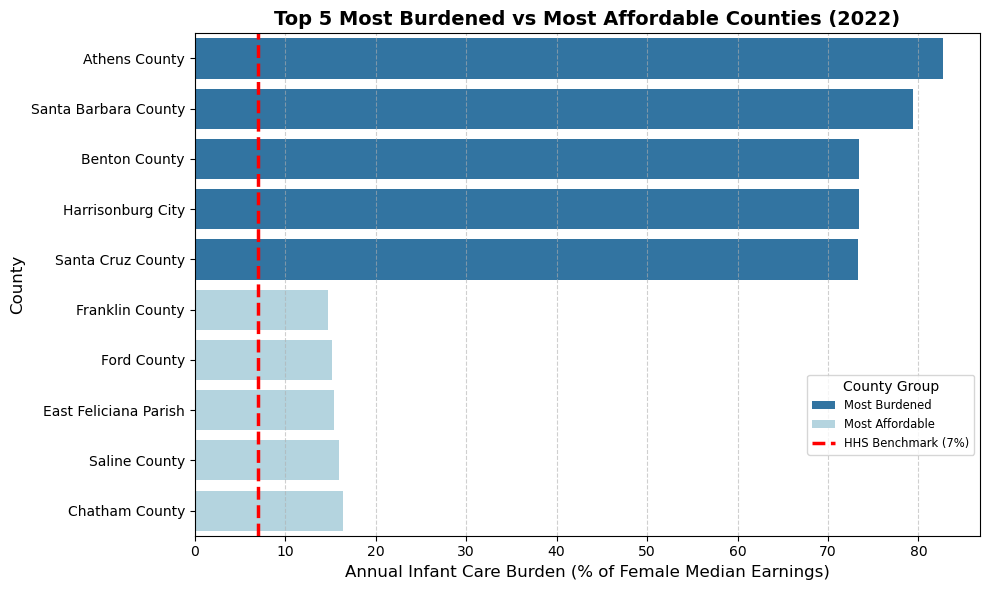

In [18]:
plt.figure(figsize=(10, 6))

# Match colors to your horizontal bar colors
palette = {'Most Burdened': 'tab:blue', 'Most Affordable': 'lightblue'}

sns.barplot(data=combined, y='COUNTY_NAME', x='annual_burden_pct_fme',
            hue='Group', dodge=False, palette=palette)

# HHS Benchmark line in red dashed
plt.axvline(7, color='red', linestyle='--', linewidth=2.5, label='HHS Benchmark (7%)')

# Titles and labels styled similarly
plt.title('Top 5 Most Burdened vs Most Affordable Counties (2022)', fontsize=14, fontweight='bold')
plt.xlabel('Annual Infant Care Burden (% of Female Median Earnings)', fontsize=12)
plt.ylabel('County', fontsize=12)

# Legend bottom right inside plot, nudged up slightly to avoid bars
plt.legend(title='County Group', loc='lower right', bbox_to_anchor=(1, 0.15), fontsize='small', framealpha=0.8)

# Add light vertical grid lines (x-axis grid lines)
plt.grid(True, axis='x', linestyle='--', alpha=0.6)

# Save the figure as PNG
plt.savefig('childcare_burden_barplot.png', dpi=300)

plt.tight_layout()
plt.show()

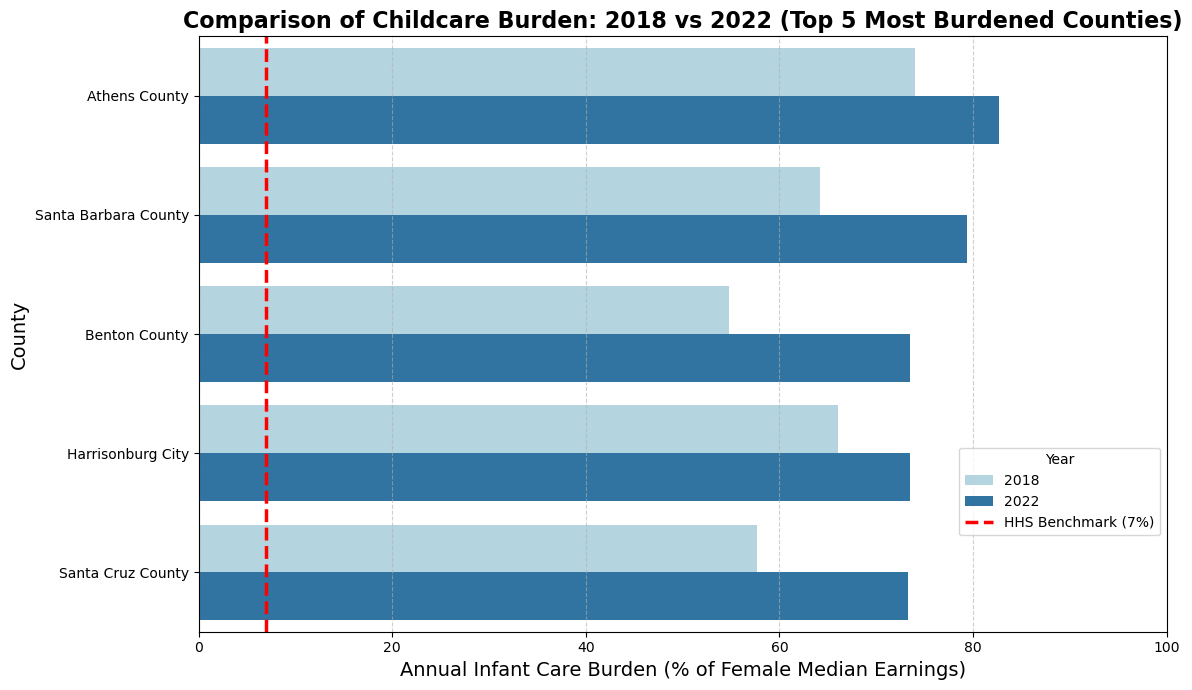

In [20]:
# Filter data for years 2018 and 2022
df_compare = df_top5_trend[df_top5_trend['YEAR'].isin([2018, 2022])]

# Pivot so counties are rows and years are columns
df_pivot = df_compare.pivot(index='COUNTY_NAME', columns='YEAR', values='annual_burden_pct_fme').reindex(sorted_counties)

# Prepare data for seaborn barplot - melt pivot back to long format with Year as string category
df_long = df_pivot.reset_index().melt(id_vars='COUNTY_NAME', value_vars=[2018, 2022], 
                                     var_name='Year', value_name='Burden')
df_long['Year'] = df_long['Year'].astype(str)

# Define color palette matching your requested colors
palette = {'2018': 'lightblue', '2022': 'tab:blue'}

plt.figure(figsize=(12, 7))

# Draw grouped barplot using seaborn
sns.barplot(data=df_long, x='Burden', y='COUNTY_NAME', hue='Year', palette=palette, dodge=True)

# Add red dashed HHS benchmark line
plt.axvline(7, color='red', linestyle='--', linewidth=2.5, label='HHS Benchmark (7%)')

# Titles and labels
plt.title('Comparison of Childcare Burden: 2018 vs 2022 (Top 5 Most Burdened Counties)', fontsize=16, fontweight='bold')
plt.xlabel('Annual Infant Care Burden (% of Female Median Earnings)', fontsize=14)
plt.ylabel('County', fontsize=14)

# Legend inside plot, bottom right, slightly nudged up
plt.legend(title='Year', loc='lower right', bbox_to_anchor=(1, 0.15), fontsize='medium', framealpha=0.8)

# Light vertical grid lines on x-axis
plt.grid(True, axis='x', linestyle='--', alpha=0.6)

# Set x-axis limits from 0 to 100
plt.xlim(0, 100)

plt.tight_layout()

# Save the figure as PNG
plt.savefig('comparison2018-2022_childcare_burden_barplot.png', dpi=300)

plt.show()

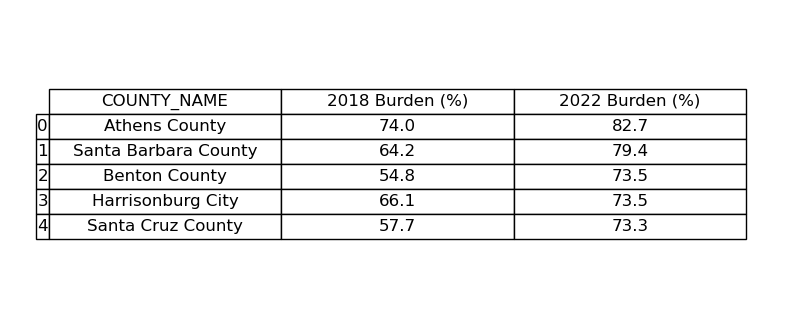

In [21]:
# Rename columns for clarity
df_table = df_pivot.rename(columns={
    2018: '2018 Burden (%)',
    2022: '2022 Burden (%)'
})

# Optional: Round values to 1 decimal
df_table = df_table.round(1)

# Reset index so COUNTY_NAME becomes a column
df_table = df_table.reset_index()

import matplotlib.pyplot as plt
from pandas.plotting import table

# Create a figure
fig, ax = plt.subplots(figsize=(10, 4))  # Adjust size as needed

# Hide axes
ax.axis('off')

# Draw table
tbl = table(ax, df_table, loc='center', cellLoc='center', colWidths=[0.25]*len(df_table.columns))

# Style (optional)
tbl.auto_set_font_size(False)
tbl.set_fontsize(12)
tbl.scale(1.2, 1.5)  # Adjust for readability

# Save as image
plt.savefig('childcare_burden_table_2018_2022.png', bbox_inches='tight', dpi=300)
plt.show()

In [22]:
# Step 1: Calculate overall medians
median_salary = df['FME_2022'].median()
median_weekly_infant_cost = df['MCINFANT'].median()

# Step 2: Compute annual infant care cost
annual_infant_cost = median_weekly_infant_cost * 52

# Step 3: Compute burden as percentage of female median earnings
burden_pct = (annual_infant_cost / median_salary) * 100

# Step 4: Display results
print(f"Median Female Earnings (2022): ${median_salary:,.2f}")
print(f"Median Weekly Infant Care Cost: ${median_weekly_infant_cost:,.2f}")
print(f"Estimated Annual Infant Care Cost: ${annual_infant_cost:,.2f}")
print(f"Childcare Burden (% of Earnings): {burden_pct:.2f}%")

Median Female Earnings (2022): $27,363.00
Median Weekly Infant Care Cost: $140.35
Estimated Annual Infant Care Cost: $7,298.20
Childcare Burden (% of Earnings): 26.67%


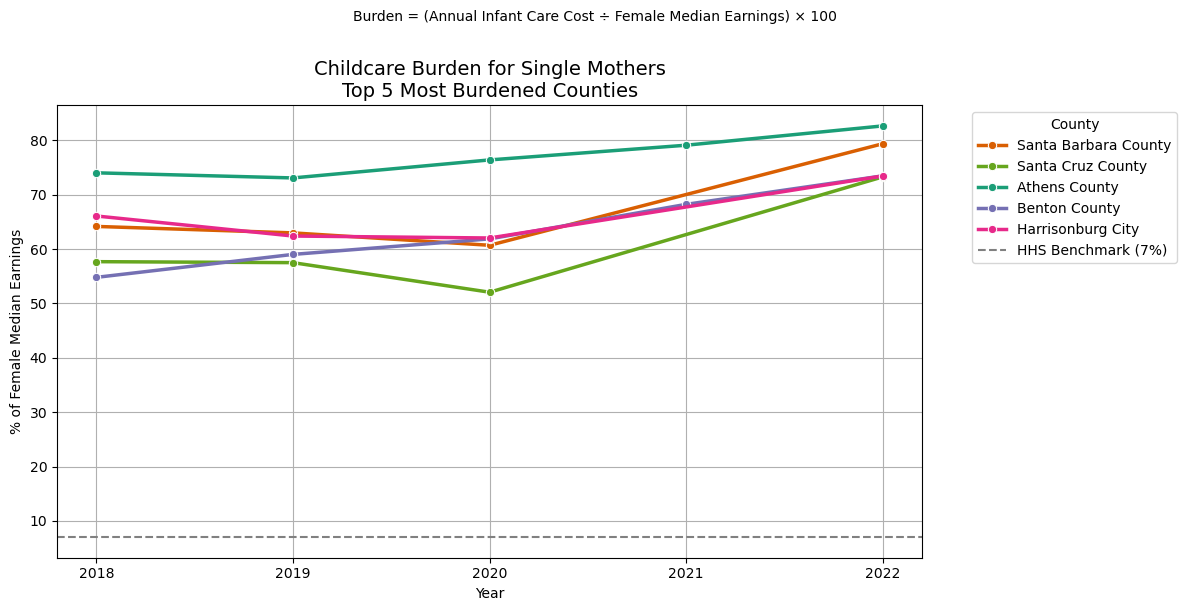

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Extract those counties for trendline analysis
top5_ids = top5_worst[['STATE_NAME', 'COUNTY_NAME']]
df_top5_trend = df_trend.merge(top5_ids, on=['STATE_NAME', 'COUNTY_NAME'])

# Sort counties for consistent color mapping
sorted_counties = top5_worst.sort_values(by='annual_burden_pct_fme', ascending=False)['COUNTY_NAME'].tolist()

# Use a distinct, professional palette
palette = sns.color_palette("Dark2", n_colors=len(sorted_counties))
county_palette = {county: palette[i] for i, county in enumerate(sorted_counties)}

# Plot: Trend line of burden over time
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_top5_trend,
    x='YEAR',
    y='annual_burden_pct_fme',
    hue='COUNTY_NAME',
    marker='o',
    linewidth=2.5,  # Thicker lines
    palette=county_palette
)

# Add benchmark line
plt.axhline(7, linestyle='--', color='gray', linewidth=1.5, label='HHS Benchmark (7%)')

# Titles and labels
plt.title('Childcare Burden for Single Mothers\nTop 5 Most Burdened Counties', fontsize=14)
plt.suptitle('Burden = (Annual Infant Care Cost ÷ Female Median Earnings) × 100', fontsize=10, y=1.01)
plt.ylabel('% of Female Median Earnings')
plt.xlabel('Year')

# Axis and legend formatting
plt.gca().xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.legend(title='County', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


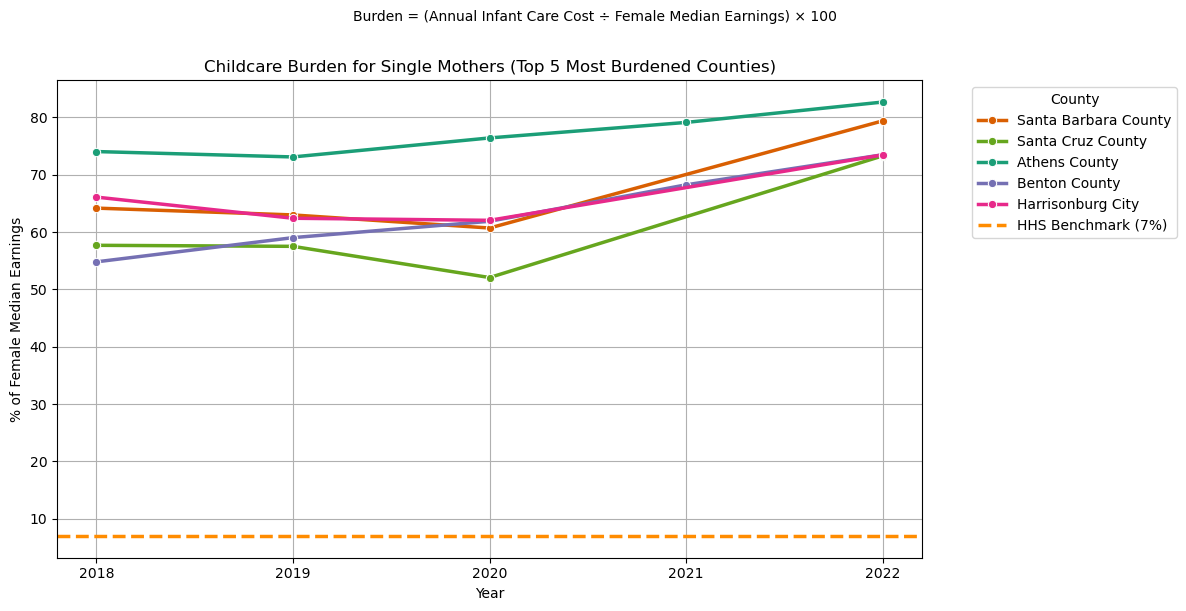

In [24]:
# Plot: Trend line of burden over time
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_top5_trend,
    x='YEAR',
    y='annual_burden_pct_fme',
    hue='COUNTY_NAME',
    marker='o',
    palette=county_palette,
    linewidth=2.5  # Thicker lines
)

# HHS Benchmark line with legend entry
plt.axhline(7, linestyle='--', color='darkorange', linewidth=2.5, label='HHS Benchmark (7%)')

plt.title('Childcare Burden for Single Mothers (Top 5 Most Burdened Counties)')
plt.suptitle('Burden = (Annual Infant Care Cost ÷ Female Median Earnings) × 100', fontsize=10, y=1.01)
plt.ylabel('% of Female Median Earnings')
plt.xlabel('Year')
plt.gca().xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.legend(title='County', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


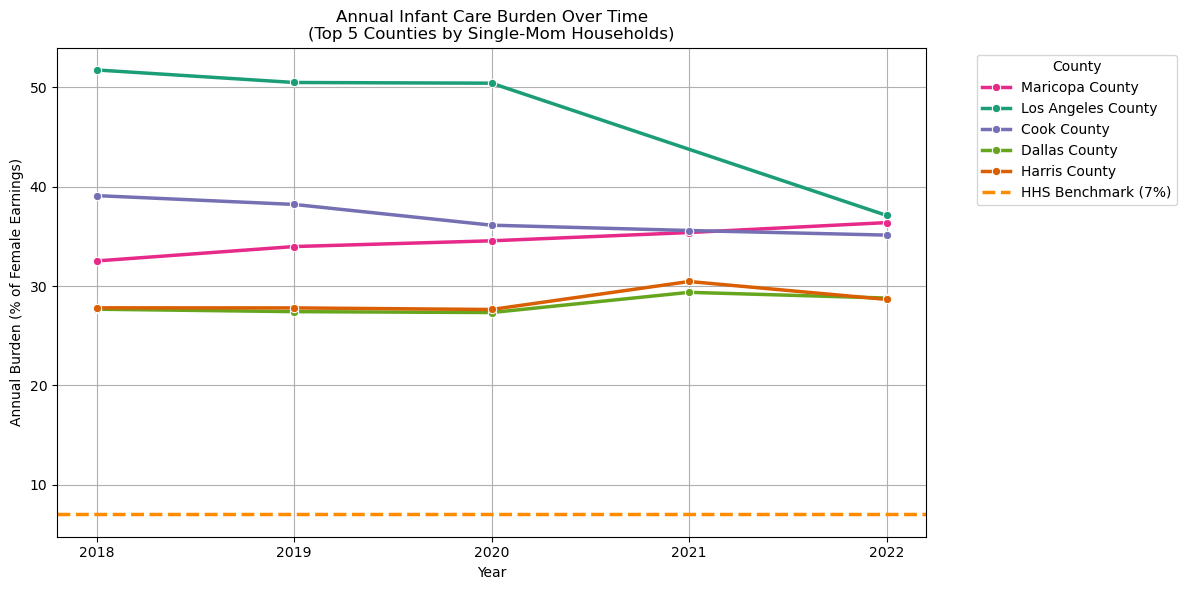

In [25]:
# Get top 5 counties with highest number of single-mom households with kids under 6
top5_single_moms = df_2022[df_2022['H_UNDER6_SINGLEM'] > 0] \
    .sort_values(by='H_UNDER6_SINGLEM', ascending=False).head(5).reset_index(drop=True)

top5_ids_single_moms = top5_single_moms[['STATE_NAME', 'COUNTY_NAME']]

# Filter trend data for just these counties
df_top5_single_moms_trend = df_trend.merge(top5_ids_single_moms, on=['STATE_NAME', 'COUNTY_NAME'])

# Set consistent color palette for counties
sorted_single_moms_counties = top5_single_moms['COUNTY_NAME'].tolist()
palette = sns.color_palette("Dark2")
county_palette_single_moms = {county: palette[i] for i, county in enumerate(sorted_single_moms_counties)}

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_top5_single_moms_trend,
    x='YEAR', y='annual_burden_pct_fme',
    hue='COUNTY_NAME', marker='o',
    palette=county_palette_single_moms,
    linewidth=2.5  # Thicker lines
)

# Add HHS Benchmark Line
plt.axhline(7, linestyle='--', color='darkorange', linewidth=2.5, label='HHS Benchmark (7%)')

# Labels and formatting
plt.title('Annual Infant Care Burden Over Time\n(Top 5 Counties by Single-Mom Households)')
plt.ylabel('Annual Burden (% of Female Earnings)')
plt.xlabel('Year')
plt.gca().xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.legend(title='County', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

In [27]:
# Get top 5 most burdened counties (using FME-based burden)
top5_worst = df_2022_moms.sort_values(by='annual_burden_pct_fme', ascending=False).head(5).reset_index(drop=True)
top5_worst.insert(0, 'Rank', range(1, len(top5_worst) + 1))

# Format columns (removed formatting for FME_2022)
top5_worst['MCINFANT'] = top5_worst['MCINFANT'].map('${:,.2f}'.format)
top5_worst['annual_burden_pct_fme'] = top5_worst['annual_burden_pct_fme'].map('{:.1f}%'.format)
top5_worst['H_UNDER6_SINGLEM'] = top5_worst['H_UNDER6_SINGLEM'].astype(int).map('{:,}'.format)

# Define columns to show (removed FME_2022)
cols_to_show = ['COUNTY_NAME', 'STATE_NAME', 'MCINFANT', 'annual_burden_pct_fme', 'H_UNDER6_SINGLEM']

# Rename columns for display
renamed_cols = {
    'COUNTY_NAME': 'County',
    'STATE_NAME': 'State',
    'MCINFANT': 'Infant Care Cost',
    'annual_burden_pct_fme': 'Annual Burden %',
    'H_UNDER6_SINGLEM': 'Single Moms w/ Child Under 6'
}

# Display
display(Markdown("### Top 5 Most Burdened Counties by Annual Infant Care Cost Burden (2022)"))
display(top5_worst[['Rank'] + cols_to_show].rename(columns=renamed_cols))

### Top 5 Most Burdened Counties by Annual Infant Care Cost Burden (2022)

,Rank,County,State,Infant Care Cost,Annual Burden %,Single Moms w/ Child Under 6
0,1,Athens County,Ohio,$295.00,82.7%,400
1,2,Santa Barbara County,California,$452.53,79.4%,"7,961"
2,3,Benton County,Oregon,$340.19,73.5%,496
3,4,Harrisonburg City,Virginia,$187.51,73.5%,490
4,5,Santa Cruz County,California,$476.88,73.3%,"3,319"


In [28]:
# Get top 5 counties with highest single-mom households in 2022
top5_single_moms = df_2022.sort_values(by='H_UNDER6_SINGLEM', ascending=False).head(5).reset_index(drop=True)
top5_single_moms.insert(0, 'Rank', range(1, len(top5_single_moms) + 1))

# Format columns to match your previous style (without formatting FME_2022)
top5_single_moms['MCINFANT'] = top5_single_moms['MCINFANT'].map('${:,.2f}'.format)
top5_single_moms['annual_burden_pct_fme'] = top5_single_moms['annual_burden_pct_fme'].map('{:.1f}%'.format)
top5_single_moms['H_UNDER6_SINGLEM'] = top5_single_moms['H_UNDER6_SINGLEM'].astype(int).map('{:,}'.format)

# Define columns to show (excluding FME_2022)
cols_to_show = ['COUNTY_NAME', 'STATE_NAME', 'MCINFANT', 'annual_burden_pct_fme', 'H_UNDER6_SINGLEM']

# Rename columns for display
renamed_cols = {
    'COUNTY_NAME': 'County',
    'STATE_NAME': 'State',
    'MCINFANT': 'Infant Care Cost',
    'annual_burden_pct_fme': 'Annual Burden %',
    'H_UNDER6_SINGLEM': 'Single Moms w/ Child Under 6'
}

# Display
display(Markdown("### Top 5 Counties by Number of Single-Mom Households (2022)"))
display(top5_single_moms[['Rank'] + cols_to_show].rename(columns=renamed_cols))

### Top 5 Counties by Number of Single-Mom Households (2022)

,Rank,County,State,Infant Care Cost,Annual Burden %,Single Moms w/ Child Under 6
0,1,Los Angeles County,California,$256.98,37.1%,"165,174"
1,2,Harris County,Texas,$185.00,28.7%,"115,198"
2,3,Cook County,Illinois,$278.33,35.1%,"96,537"
3,4,Maricopa County,Arizona,$270.00,36.4%,"77,126"
4,5,Dallas County,Texas,$194.00,28.8%,"63,034"


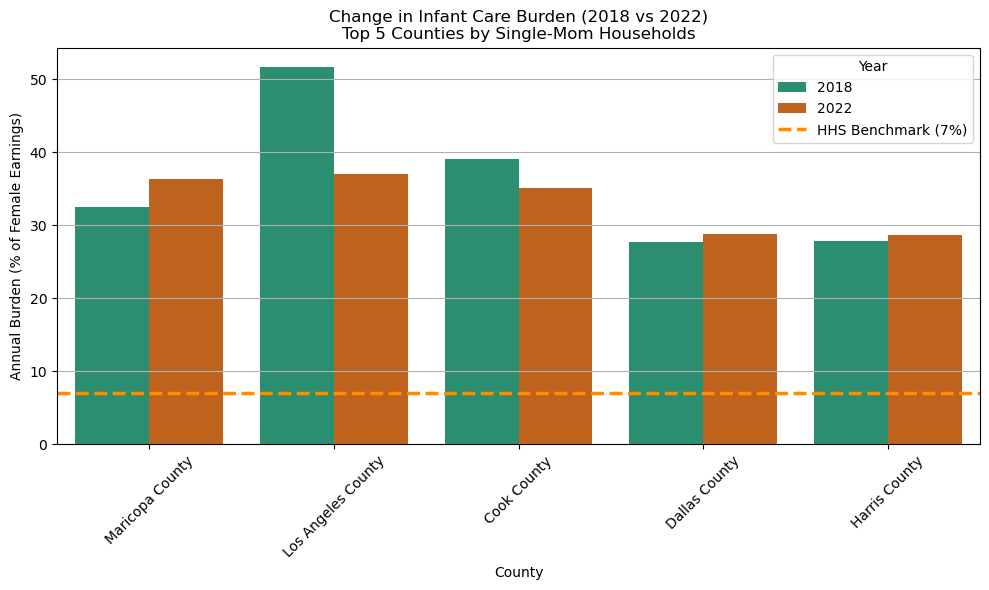

In [29]:
# Filter to only 2018 and 2022 data for the top 5 counties
df_compare_years = df_top5_single_moms_trend[df_top5_single_moms_trend['YEAR'].isin([2018, 2022])]

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_compare_years,
    x='COUNTY_NAME', y='annual_burden_pct_fme', hue='YEAR',
    palette='Dark2'
)

# Add HHS Benchmark line
plt.axhline(7, linestyle='--', color='darkorange', linewidth=2.5, label='HHS Benchmark (7%)')

# Labels and formatting
plt.title('Change in Infant Care Burden (2018 vs 2022)\nTop 5 Counties by Single-Mom Households')
plt.ylabel('Annual Burden (% of Female Earnings)')
plt.xlabel('County')
plt.legend(title='Year')
plt.xticks(rotation=45)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

C:\Users\samue\AppData\Local\Temp\ipykernel_6004\2395025160.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


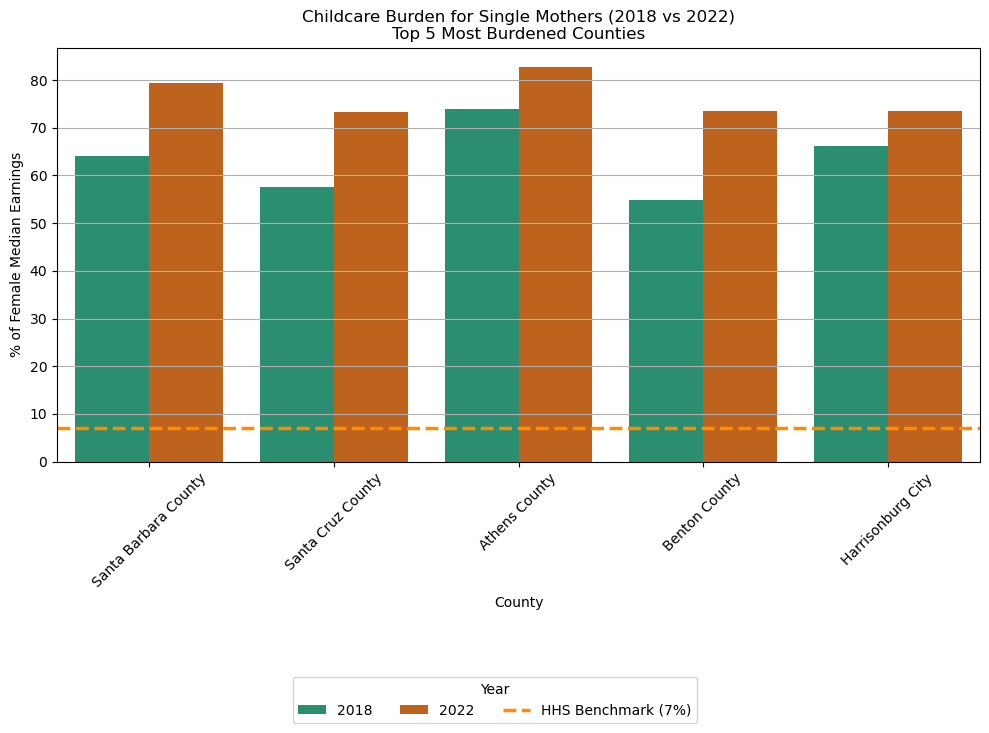

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up figure and axis using subplots
fig, ax = plt.subplots(figsize=(10, 7))  # Taller figure

# Plot
sns.barplot(
    data=df_compare_years_trend,
    x='COUNTY_NAME',
    y='annual_burden_pct_fme',
    hue='YEAR',
    palette='Dark2',
    ax=ax
)

# Add HHS Benchmark line
ax.axhline(7, linestyle='--', color='darkorange', linewidth=2.5, label='HHS Benchmark (7%)')

# Titles and labels
ax.set_title('Childcare Burden for Single Mothers (2018 vs 2022)\nTop 5 Most Burdened Counties')
ax.set_ylabel('% of Female Median Earnings')
ax.set_xlabel('County')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.grid(True, axis='y')

# Create a separate legend below the plot
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, title='Year', loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=3)

# Adjust layout so nothing overlaps
plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave room at bottom for legend

if ax.get_legend() is not None:
    ax.get_legend().remove()

# Show
plt.show()